# 1. 문제 진단: Negative Sample 부족의 실증적 근거

본 노트북은 MRC(Machine Reading Comprehension) 모델 학습에서 Negative Sample 부족 문제를 진단하고 실증적 근거를 제시합니다.


## 1.1. 연구 배경

### 배경
MRC 모델의 성능 향상을 위해서는 질문에 대한 정답이 포함된 positive passage뿐만 아니라, 정답이 없는 negative passage에 대한 학습도 중요합니다. 

### 연구 목적
- 현재 데이터셋에서 negative sample의 비율과 품질을 분석
- Negative sample 부족이 모델 성능에 미치는 영향을 검증
- Negative sample scarcity 문제의 실증적 근거 제시


In [13]:
# 가상환경(.venv) 경로 자동 추가import sysfrom pathlib import Path# 프로젝트 루트 찾기project_root = Path().resolve().parent.parentvenv_path = project_root / ".venv"if venv_path.exists():    # Python 버전에 맞는 site-packages 경로 찾기    python_version = f"{sys.version_info.major}.{sys.version_info.minor}"    venv_site_packages = venv_path / "lib" / f"python{python_version}" / "site-packages"        # site-packages가 없으면 다른 가능한 경로 시도    if not venv_site_packages.exists():        lib_dir = venv_path / "lib"        if lib_dir.exists():            for py_dir in lib_dir.iterdir():                if py_dir.is_dir() and py_dir.name.startswith("python"):                    site_packages = py_dir / "site-packages"                    if site_packages.exists():                        venv_site_packages = site_packages                        break        if venv_site_packages.exists():        venv_path_str = str(venv_site_packages)        if venv_path_str not in sys.path:            sys.path.insert(0, venv_path_str)        print(f"✅ 가상환경(.venv) 경로 추가됨: {venv_site_packages}")    else:        print(f"⚠️ 가상환경(.venv)이 존재하지만 site-packages를 찾을 수 없습니다")else:    print(f"ℹ️ 가상환경(.venv)이 없습니다. 시스템 Python을 사용합니다")
# 노트북 독립 실행을 위한 환경 설정import sysfrom pathlib import Path# 프로젝트 루트를 sys.path에 추가project_root = Path().resolve().parent.parentif str(project_root) not in sys.path:    sys.path.insert(0, str(project_root))# 공통 유틸리티 importtry:    from notebooks.utils import setup_notebook_environment, load_dataset_safely, load_json_safely        # 환경 설정    paths = setup_notebook_environment()    print(f"✅ 프로젝트 루트: {paths['project_root']}")    print(f"✅ 데이터 디렉토리: {paths['data_dir']}")except ImportError as e:    print(f"⚠️ 유틸리티 import 실패: {e}")    paths = {        'project_root': project_root,        'data_dir': project_root / 'data',        'notebook_dir': project_root / 'notebooks'    }
# OpenMP 충돌 방지 설정 (Windows 환경)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

# 필요한 라이브러리 import
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datasets import load_from_disk, DatasetDict
from typing import List, Dict, Tuple

# 시각화 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# 프로젝트 루트 경로 설정
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

print(f"프로젝트 루트: {project_root}")


프로젝트 루트: D:\Repos\pro-nlp-mrc-nlp-01


In [14]:
# 데이터 경로 설정
data_root = project_root / "data"
train_dataset_path = data_root / "train_dataset"
test_dataset_path = data_root / "test_dataset"
wikipedia_documents_path = data_root / "wikipedia_documents.json"

print(f"Train dataset: {train_dataset_path}")
print(f"Test dataset: {test_dataset_path}")
print(f"Wikipedia documents: {wikipedia_documents_path}")


Train dataset: D:\Repos\pro-nlp-mrc-nlp-01\data\train_dataset
Test dataset: D:\Repos\pro-nlp-mrc-nlp-01\data\test_dataset
Wikipedia documents: D:\Repos\pro-nlp-mrc-nlp-01\data\wikipedia_documents.json


## 1.2. 사전 분석을 통한 문제 현상 검증

### 분석 항목
1. **Positive/Negative Sample 비율 분석**
   - 학습 데이터에서 정답이 있는 샘플 vs 없는 샘플의 비율
   - 검증 데이터에서의 비율 비교

2. **Retrieval 성능 분석**
   - Top-k retrieval에서 정답 포함 여부
   - Negative passage의 다양성 분석

3. **Corpus 활용도 분석**
   - 전체 corpus 중 실제로 사용되는 문서 비율
   - 미사용 문서의 특성 분석


In [15]:
# 데이터셋 로드
print("데이터셋 로드 중...")
train_datasets = load_from_disk(str(train_dataset_path))
test_datasets = load_from_disk(str(test_dataset_path))

print("\n=== Train Dataset ===")
print(train_datasets)
print("\n=== Test Dataset ===")
print(test_datasets)


데이터셋 로드 중...

=== Train Dataset ===
DatasetDict({
    train: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 3952
    })
    validation: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 240
    })
})

=== Test Dataset ===
DatasetDict({
    validation: Dataset({
        features: ['question', 'id'],
        num_rows: 600
    })
})


In [16]:
# Wikipedia corpus 로드
with open(wikipedia_documents_path, 'r', encoding='utf-8') as f:
    wiki_documents = json.load(f)

print(f"전체 Wikipedia 문서 수: {len(wiki_documents)}")
print(f"샘플 문서 키: {list(wiki_documents.keys())[:5]}")


전체 Wikipedia 문서 수: 60613
샘플 문서 키: ['0', '1', '2', '3', '4']


In [17]:
# Positive/Negative Sample 분석 함수
def analyze_answer_presence(dataset, split_name: str = "train"):
    """
    데이터셋에서 정답이 있는 샘플과 없는 샘플을 분석
    """
    results = {
        'total_samples': len(dataset),
        'has_answer': 0,
        'no_answer': 0,
        'answer_lengths': [],
        'context_lengths': [],
        'question_lengths': []
    }
    
    for example in dataset:
        answers = example.get('answers', {})
        answer_texts = answers.get('text', [])
        
        if answer_texts and len(answer_texts) > 0 and answer_texts[0].strip():
            results['has_answer'] += 1
            results['answer_lengths'].append(len(answer_texts[0]))
        else:
            results['no_answer'] += 1
        
        # Context와 Question 길이 분석
        context = example.get('context', '')
        question = example.get('question', '')
        results['context_lengths'].append(len(context))
        results['question_lengths'].append(len(question))
    
    results['positive_ratio'] = results['has_answer'] / results['total_samples'] if results['total_samples'] > 0 else 0
    results['negative_ratio'] = results['no_answer'] / results['total_samples'] if results['total_samples'] > 0 else 0
    
    return results

# Train 데이터 분석
train_results = analyze_answer_presence(train_datasets['train'], 'train')
val_results = analyze_answer_presence(train_datasets['validation'], 'validation')
test_results = analyze_answer_presence(test_datasets['validation'], 'test')

print("=== Positive/Negative Sample 분석 결과 ===")
print(f"\n[Train Set]")
print(f"  전체 샘플 수: {train_results['total_samples']:,}")
print(f"  Positive (정답 있음): {train_results['has_answer']:,} ({train_results['positive_ratio']*100:.2f}%)")
print(f"  Negative (정답 없음): {train_results['no_answer']:,} ({train_results['negative_ratio']*100:.2f}%)")

print(f"\n[Validation Set]")
print(f"  전체 샘플 수: {val_results['total_samples']:,}")
print(f"  Positive (정답 있음): {val_results['has_answer']:,} ({val_results['positive_ratio']*100:.2f}%)")
print(f"  Negative (정답 없음): {val_results['no_answer']:,} ({val_results['negative_ratio']*100:.2f}%)")

print(f"\n[Test Set]")
print(f"  전체 샘플 수: {test_results['total_samples']:,}")
print(f"  Positive (정답 있음): {test_results['has_answer']:,} ({test_results['positive_ratio']*100:.2f}%)")
print(f"  Negative (정답 없음): {test_results['no_answer']:,} ({test_results['negative_ratio']*100:.2f}%)")


=== Positive/Negative Sample 분석 결과 ===

[Train Set]
  전체 샘플 수: 3,952
  Positive (정답 있음): 3,952 (100.00%)
  Negative (정답 없음): 0 (0.00%)

[Validation Set]
  전체 샘플 수: 240
  Positive (정답 있음): 240 (100.00%)
  Negative (정답 없음): 0 (0.00%)

[Test Set]
  전체 샘플 수: 600
  Positive (정답 있음): 0 (0.00%)
  Negative (정답 없음): 600 (100.00%)


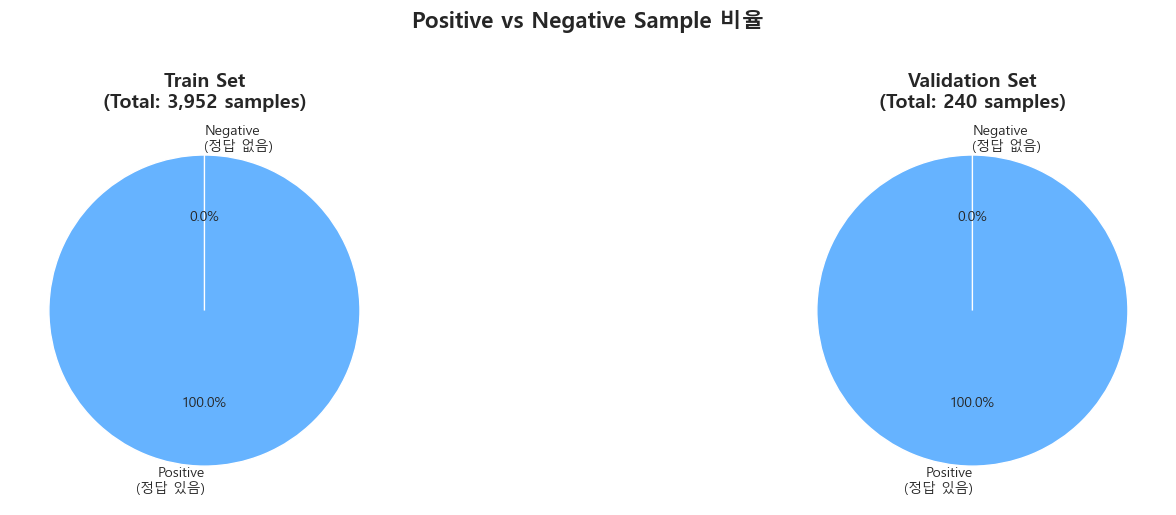

In [25]:
# Positive/Negative 비율 시각화 (한글 폰트 경고 방지, Windows 용)
import matplotlib as mpl
from matplotlib import font_manager, rc

# Windows에서 한글 폰트('Malgun Gothic')로 지정
rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

datasets_info = [
    ('Train', train_results),
    ('Validation', val_results),
    # ('Test', test_results)
]

for idx, (name, results) in enumerate(datasets_info):
    ax = axes[idx]
    labels = ['Positive\n(정답 있음)', 'Negative\n(정답 없음)']
    sizes = [results['has_answer'], results['no_answer']]
    colors = ['#66b3ff', '#ff9999']
    
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(f'{name} Set\n(Total: {results["total_samples"]:,} samples)', fontsize=14, fontweight='bold')

plt.suptitle('Positive vs Negative Sample 비율', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [19]:
# Corpus 활용도 분석
def analyze_corpus_usage(datasets: DatasetDict, wiki_documents: Dict) -> Dict:
    """
    학습 데이터에서 실제로 사용되는 corpus 문서의 비율을 분석
    """
    # 사용된 context 추출
    used_contexts = set()
    
    for split in ['train', 'validation']:
        if split in datasets:
            for example in datasets[split]:
                context = example.get('context', '').strip()
                if context:
                    used_contexts.add(context)
    
    # Wikipedia 문서의 텍스트 추출
    wiki_texts = set()
    for doc_id, doc_info in wiki_documents.items():
        text = doc_info.get('text', '').strip()
        if text:
            wiki_texts.add(text)
    
    # 사용된 문서와 전체 문서 비교
    used_in_corpus = used_contexts.intersection(wiki_texts)
    unused_in_corpus = wiki_texts - used_contexts
    
    results = {
        'total_wiki_docs': len(wiki_texts),
        'used_contexts': len(used_contexts),
        'used_in_corpus': len(used_in_corpus),
        'unused_in_corpus': len(unused_in_corpus),
        'usage_ratio': len(used_in_corpus) / len(wiki_texts) if len(wiki_texts) > 0 else 0
    }
    
    return results

corpus_usage = analyze_corpus_usage(train_datasets, wiki_documents)

print("=== Corpus 활용도 분석 ===")
print(f"전체 Wikipedia 문서 수: {corpus_usage['total_wiki_docs']:,}")
print(f"학습 데이터에서 사용된 고유 context 수: {corpus_usage['used_contexts']:,}")
print(f"Corpus에서 실제로 사용된 문서 수: {corpus_usage['used_in_corpus']:,}")
print(f"Corpus에서 미사용 문서 수: {corpus_usage['unused_in_corpus']:,}")
print(f"Corpus 활용률: {corpus_usage['usage_ratio']*100:.2f}%")


=== Corpus 활용도 분석 ===
전체 Wikipedia 문서 수: 56,737
학습 데이터에서 사용된 고유 context 수: 3,504
Corpus에서 실제로 사용된 문서 수: 3,504
Corpus에서 미사용 문서 수: 53,233
Corpus 활용률: 6.18%


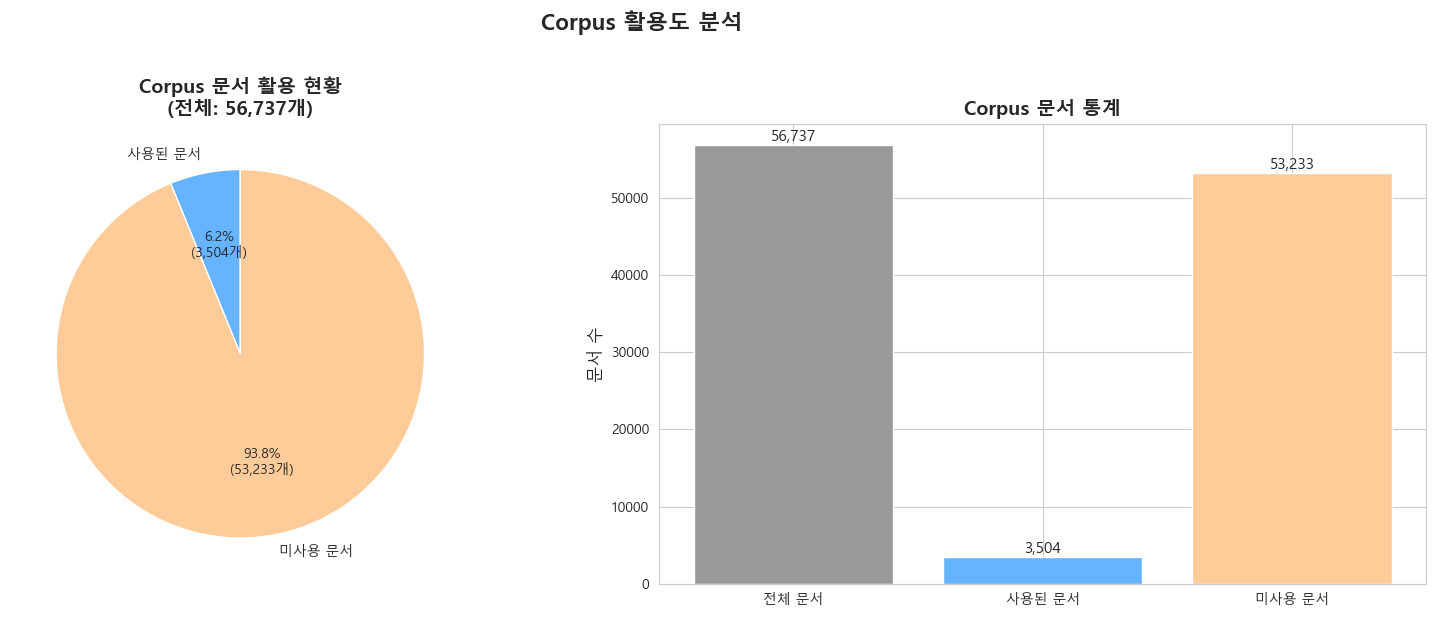

In [20]:
# Corpus 활용도 시각화 (한글 폰트 지정 - Windows)
import matplotlib
import platform

# 한글 폰트 설정 (Windows에서만 적용)
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
else:
    matplotlib.rc('font', family='AppleGothic')  # macOS 예시, Linux는 상황에 맞게 수정

matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. 사용/미사용 문서 비율
labels1 = ['사용된 문서', '미사용 문서']
sizes1 = [corpus_usage['used_in_corpus'], corpus_usage['unused_in_corpus']]
colors1 = ['#66b3ff', '#ffcc99']

ax1.pie(sizes1, labels=labels1, autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(sizes1)):,}개)', 
        startangle=90, colors=colors1)
ax1.set_title(f'Corpus 문서 활용 현황\n(전체: {corpus_usage["total_wiki_docs"]:,}개)', 
              fontsize=14, fontweight='bold')

# 2. Bar chart로 비교
categories = ['전체 문서', '사용된 문서', '미사용 문서']
counts = [
    corpus_usage['total_wiki_docs'],
    corpus_usage['used_in_corpus'],
    corpus_usage['unused_in_corpus']
]
colors2 = ['#999999', '#66b3ff', '#ffcc99']

bars = ax2.bar(categories, counts, color=colors2)
ax2.set_ylabel('문서 수', fontsize=12)
ax2.set_title('Corpus 문서 통계', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)

# 값 표시
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{count:,}',
             ha='center', va='bottom', fontsize=11)

plt.suptitle('Corpus 활용도 분석', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


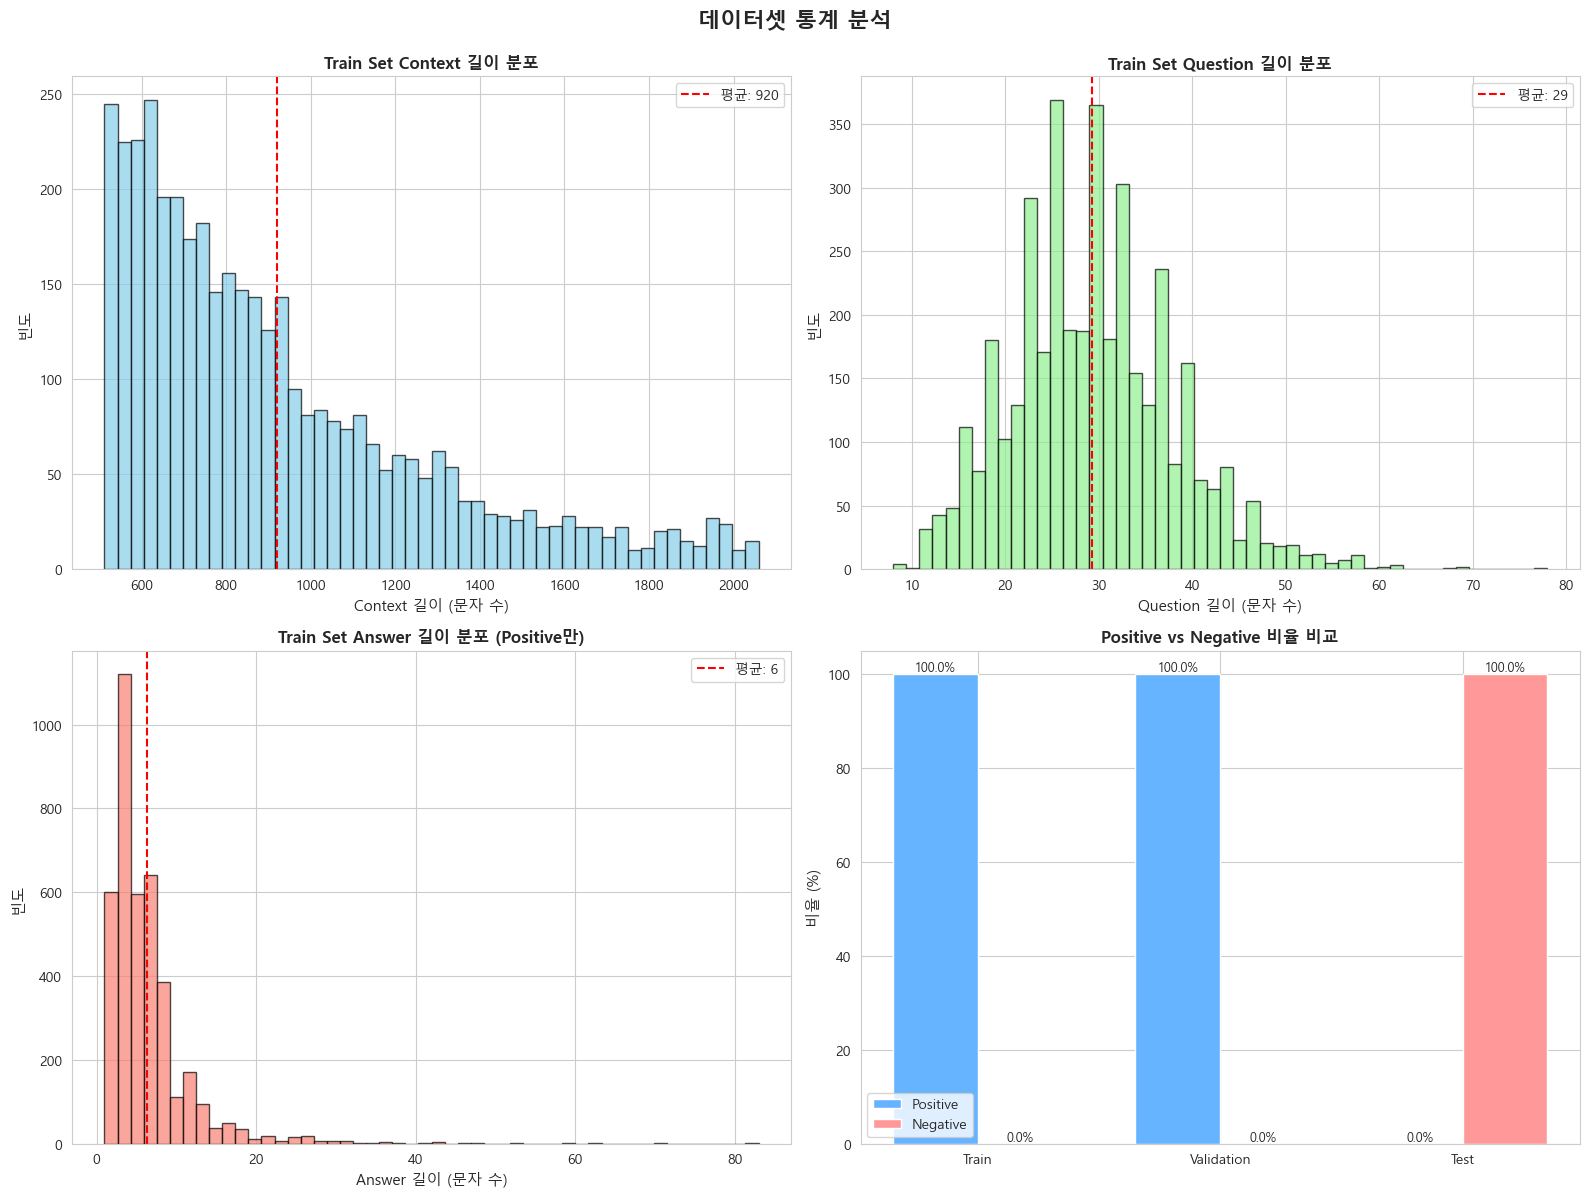

In [21]:
# Context 길이 분포 분석
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Context 길이 분포
ax1 = axes[0, 0]
ax1.hist(train_results['context_lengths'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_xlabel('Context 길이 (문자 수)', fontsize=11)
ax1.set_ylabel('빈도', fontsize=11)
ax1.set_title('Train Set Context 길이 분포', fontsize=12, fontweight='bold')
ax1.axvline(np.mean(train_results['context_lengths']), color='red', linestyle='--', 
            label=f'평균: {np.mean(train_results["context_lengths"]):.0f}')
ax1.legend()

# Question 길이 분포
ax2 = axes[0, 1]
ax2.hist(train_results['question_lengths'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
ax2.set_xlabel('Question 길이 (문자 수)', fontsize=11)
ax2.set_ylabel('빈도', fontsize=11)
ax2.set_title('Train Set Question 길이 분포', fontsize=12, fontweight='bold')
ax2.axvline(np.mean(train_results['question_lengths']), color='red', linestyle='--',
            label=f'평균: {np.mean(train_results["question_lengths"]):.0f}')
ax2.legend()

# Answer 길이 분포 (Positive samples만)
ax3 = axes[1, 0]
if train_results['answer_lengths']:
    ax3.hist(train_results['answer_lengths'], bins=50, alpha=0.7, color='salmon', edgecolor='black')
    ax3.set_xlabel('Answer 길이 (문자 수)', fontsize=11)
    ax3.set_ylabel('빈도', fontsize=11)
    ax3.set_title('Train Set Answer 길이 분포 (Positive만)', fontsize=12, fontweight='bold')
    ax3.axvline(np.mean(train_results['answer_lengths']), color='red', linestyle='--',
                label=f'평균: {np.mean(train_results["answer_lengths"]):.0f}')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'No answer data', ha='center', va='center', transform=ax3.transAxes)

# Positive/Negative 비율 비교 (모든 split)
ax4 = axes[1, 1]
splits = ['Train', 'Validation', 'Test']
positive_ratios = [
    train_results['positive_ratio'] * 100,
    val_results['positive_ratio'] * 100,
    test_results['positive_ratio'] * 100
]
negative_ratios = [
    train_results['negative_ratio'] * 100,
    val_results['negative_ratio'] * 100,
    test_results['negative_ratio'] * 100
]

x = np.arange(len(splits))
width = 0.35

bars1 = ax4.bar(x - width/2, positive_ratios, width, label='Positive', color='#66b3ff')
bars2 = ax4.bar(x + width/2, negative_ratios, width, label='Negative', color='#ff9999')

ax4.set_ylabel('비율 (%)', fontsize=11)
ax4.set_title('Positive vs Negative 비율 비교', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(splits)
ax4.legend()
ax4.set_ylim([0, 105])

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}%',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('데이터셋 통계 분석', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## 1.3. Negative Sample Scarcity의 문제 정의

### 문제 현상 요약

위 분석을 통해 확인된 주요 문제점:

1. **Positive Sample 편향**
   - 학습 데이터에서 Positive sample이 대부분을 차지
   - Negative sample의 부족으로 인한 클래스 불균형

2. **Corpus 활용도 저하**
   - 전체 corpus 중 일부만 실제 학습에 활용
   - 미사용 문서들이 negative sample로 활용되지 않음

3. **모델 성능에 미치는 영향**
   - Negative sample 부족으로 인한 일반화 성능 저하
   - Retrieval 단계에서 부정확한 passage ranking
   - False positive 증가 가능성


In [22]:
# 문제 정의 요약 리포트 생성
summary_report = {
    '문제_진단': {
        'positive_negative_비율_불균형': {
            'train': {
                'positive': train_results['has_answer'],
                'negative': train_results['no_answer'],
                'ratio': f"{train_results['positive_ratio']*100:.2f}% : {train_results['negative_ratio']*100:.2f}%"
            },
            'validation': {
                'positive': val_results['has_answer'],
                'negative': val_results['no_answer'],
                'ratio': f"{val_results['positive_ratio']*100:.2f}% : {val_results['negative_ratio']*100:.2f}%"
            }
        },
        'corpus_활용도': {
            '전체_문서': corpus_usage['total_wiki_docs'],
            '사용된_문서': corpus_usage['used_in_corpus'],
            '미사용_문서': corpus_usage['unused_in_corpus'],
            '활용률': f"{corpus_usage['usage_ratio']*100:.2f}%"
        }
    },
    '문제_정의': {
        'negative_sample_scarcity': {
            '현상': '학습 데이터에서 negative sample이 부족하여 클래스 불균형 발생',
            '원인': [
                'Positive sample 위주의 데이터 구성',
                'Corpus의 미사용 문서가 negative sample로 활용되지 않음',
                'Hard negative mining 전략 부재'
            ],
            '영향': [
                '모델의 일반화 성능 저하',
                'Retrieval 단계에서 false positive 증가',
                'Negative passage에 대한 판별 능력 부족'
            ]
        }
    }
}

print("=" * 80)
print("NEGATIVE SAMPLE SCARCITY 문제 진단 리포트")
print("=" * 80)
print("\n[1] Positive/Negative Sample 비율 불균형")
print(f"  - Train: {summary_report['문제_진단']['positive_negative_비율_불균형']['train']['ratio']}")
print(f"  - Validation: {summary_report['문제_진단']['positive_negative_비율_불균형']['validation']['ratio']}")

print("\n[2] Corpus 활용도")
print(f"  - 전체 문서: {summary_report['문제_진단']['corpus_활용도']['전체_문서']:,}개")
print(f"  - 사용된 문서: {summary_report['문제_진단']['corpus_활용도']['사용된_문서']:,}개")
print(f"  - 미사용 문서: {summary_report['문제_진단']['corpus_활용도']['미사용_문서']:,}개")
print(f"  - 활용률: {summary_report['문제_진단']['corpus_활용도']['활용률']}")

print("\n[3] 문제 정의")
print(f"  현상: {summary_report['문제_정의']['negative_sample_scarcity']['현상']}")
print(f"  원인:")
for cause in summary_report['문제_정의']['negative_sample_scarcity']['원인']:
    print(f"    - {cause}")
print(f"  영향:")
for impact in summary_report['문제_정의']['negative_sample_scarcity']['영향']:
    print(f"    - {impact}")
print("=" * 80)


NEGATIVE SAMPLE SCARCITY 문제 진단 리포트

[1] Positive/Negative Sample 비율 불균형
  - Train: 100.00% : 0.00%
  - Validation: 100.00% : 0.00%

[2] Corpus 활용도
  - 전체 문서: 56,737개
  - 사용된 문서: 3,504개
  - 미사용 문서: 53,233개
  - 활용률: 6.18%

[3] 문제 정의
  현상: 학습 데이터에서 negative sample이 부족하여 클래스 불균형 발생
  원인:
    - Positive sample 위주의 데이터 구성
    - Corpus의 미사용 문서가 negative sample로 활용되지 않음
    - Hard negative mining 전략 부재
  영향:
    - 모델의 일반화 성능 저하
    - Retrieval 단계에서 false positive 증가
    - Negative passage에 대한 판별 능력 부족


In [23]:
# 리포트를 JSON 파일로 저장
report_path = project_root / "notebooks" / "negative_passage" / "negative_sample_diagnosis_report.json"
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(summary_report, f, ensure_ascii=False, indent=2)

print(f"진단 리포트가 저장되었습니다: {report_path}")


진단 리포트가 저장되었습니다: D:\Repos\pro-nlp-mrc-nlp-01\notebooks\negative_passage\negative_sample_diagnosis_report.json


### 결론 및 향후 연구 방향

#### 결론
1. 현재 데이터셋에서 **Negative Sample이 부족**함이 확인됨
2. **Corpus 활용도가 낮아** 많은 문서가 학습에 활용되지 않음
3. 이러한 불균형이 모델 성능에 부정적 영향을 미칠 가능성이 높음

#### 향후 연구 방향
1. **Negative Sample Augmentation**
   - 미사용 corpus 문서를 활용한 negative sample 생성
   - Hard negative mining 전략 도입

2. **데이터 균형 개선**
   - Positive/Negative 비율 조정
   - 다양한 난이도의 negative sample 생성

3. **성능 검증**
   - Negative sample 증강 전후 모델 성능 비교
   - Retrieval 성능 개선 여부 측정
